# **医学数据分类：心脏病预测模型**

## **🎯 本次课目标**
本次课我们将学习如何使用监督学习方法构建心脏病预测模型，根据患者的各项医学指标预测其是否患有心脏病。

**应用场景**：医院希望根据患者的体检数据（如血压、胆固醇、心电图等）自动预测其心脏病风险，辅助医生进行早期诊断和干预。

## **📚 知识点预览**
1. **分类的基本概念**：什么是分类？分类与聚类、回归有什么区别？
2. **数据处理**：特征选择、数据划分（训练集/测试集）
3. **分类算法**：逻辑回归、决策树、随机森林、支持向量机（SVM）等经典分类算法
4. **模型评估**：准确率、精确率、召回率、F1分数
5. **医学应用**：理解模型在临床实践中的意义

---
# **第一部分：分类的基本概念**

## **🔍 什么是分类？**

**通俗理解**：
分类就是给数据'打标签'或'归类'。

**生活类比**：
- 垃圾分类：将垃圾分为'可回收'、'厨余'、'有害'等类别
- 邮件分类：将邮件分为'正常邮件'和'垃圾邮件'
- 医生诊断：根据症状判断患者'患病'或'不患病'

**核心要素**：
- **特征**（Features）：用于做判断的依据（如血压、胆固醇）
- **标签**（Labels）：预测的目标（如'患病'或'不患病'）
- **模型**（Model）：从特征到标签的映射关系

**监督学习**：分类属于监督学习，需要使用带标签的训练数据来学习模型。

## **⚖️ 分类 vs 聚类 vs 回归**

这三种方法是机器学习中最基础的方法，理解它们的区别非常重要：

| 方法 | 标签 | 目标 | 输出类型 | 例子 |
|------|------|------|----------|------|
| **分类** | 有 | 预测离散类别 | 类别（0/1, A/B/C） | 预测心脏病（是/否） |
| **聚类** | 无 | 发现数据结构 | 簇编号 | 自动分组患者类型 |
| **回归** | 有 | 预测连续数值 | 数值（如价格、年龄） | 预测预期寿命 |

### **1. 分类 vs 聚类**

**关键区别**：
- **分类（有监督）**：先告诉计算机'什么是对的'，让它学习规律
  - 例子：给模型看1000个心脏病患者和1000个健康人，让它学会区分
  - 特点：需要标注数据，目标是预测未知样本的标签

- **聚类（无监督）**：不告诉计算机'什么是对的'，让它自己发现规律
  - 例子：给模型看2000个患者，让它自己发现哪些人相似
  - 特点：不需要标注数据，目标是发现数据的内在结构

**医学类比**：
- **分类**：医学院学生学习典型病例，考试时诊断新病人
- **聚类**：流行病学家分析人群数据，发现新的疾病亚型

**在心脏病数据上的应用**：
- **分类**：使用已有的诊断结果（target=0/1），训练模型预测新患者是否患病
- **聚类**：不看target，将患者自动分组，可能发现'高风险型'、'中风险型'、'低风险型'

### **2. 分类 vs 回归**

**关键区别**：输出的类型不同

- **分类**：输出是**离散的类别**
  - 二分类：是/否、男/女、患病/健康
  - 多分类：A型/B型/C型、轻度/中度/重度
  - 在心脏病数据中：target=0（不患病）或 target=1（患病）

- **回归**：输出是**连续的数值**
  - 可以是任意实数：12.5、98.3、-5.2
  - 在心脏病数据中的例子：预测患者的'预期寿命'或'心脏病风险概率'（0.85表示85%概率患病）

**数学区别**：
- 分类：预测y ∈ {0, 1, 2, ...}（离散集合）
- 回归：预测y ∈ R（实数域）

**生活类比**：
- **分类**：预测明天的天气是'晴天'、'阴天'还是'雨天'（3个类别）
- **回归**：预测明天的具体温度是23.5°C（连续数值）

### **3. 三种方法的对比总结**

```
机器学习方法
    |
    |-- 有监督学习（需要标签）
    |   |-- 分类 → 预测离散类别
    |   |   |-- 例子：心脏病预测（是/否）
    |   |
    |   |-- 回归 → 预测连续数值
    |       |-- 例子：预测预期寿命（年）
    |
    |-- 无监督学习（不需要标签）
        |-- 聚类 → 发现数据结构
            |-- 例子：患者自动分组
```

**在心脏病数据上的应用对比**：

| 方法 | 输入 | 输出 | 应用场景 |
|------|------|------|----------|
| **分类** | 患者13项指标 + 已知诊断 | 预测新患者是否患病 | 辅助诊断 |
| **回归** | 患者13项指标 + 已知年龄 | 预测新患者年龄 | 年龄估算 |
| **聚类** | 患者13项指标（不含诊断） | 将患者分组 | 风险分层 |

## **🏥 医学中的分类应用**

分类在医学领域有广泛的应用：

**1. 风险预测**
- 预测患者未来发生并发症的风险
- 高/中/低风险分层

**2. 疾病诊断**
- 根据症状、检查结果判断是否患病
- 心脏病、糖尿病、癌症等疾病的早期筛查

**3. 治疗响应预测**
- 预测患者对某种治疗方案是否有效
- 个性化治疗方案选择

**4. 图像识别**
- X光片、CT、MRI图像的自动分析
- 识别肿瘤、病变等异常

---
# **第二部分：环境准备和数据加载**

## **2.1 环境准备**

和第三周一样，我们需要导入必要的Python库。

In [1]:
# 导入数据处理的核心库
import numpy as np   # 数值计算工具
import pandas as pd  # 数据表格处理工具

# 导入可视化工具
import matplotlib.pyplot as plt  # 基础绘图
import seaborn as sns            # 更美观的统计图表

# 导入机器学习工具
from sklearn.model_selection import train_test_split  # 数据划分
from sklearn.preprocessing import StandardScaler      # 数据标准化
from sklearn.linear_model import LogisticRegression    # 逻辑回归分类器
from sklearn.tree import DecisionTreeClassifier        # 决策树分类器
from sklearn.ensemble import RandomForestClassifier    # 随机森林分类器
from sklearn.svm import SVC                            # 支持向量机分类器
from sklearn.metrics import (accuracy_score, precision_score, 
                           recall_score, f1_score,
                           confusion_matrix, classification_report,
                           roc_curve, auc)            # 模型评估指标

# 设置图表显示参数
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 忽略警告
import warnings
warnings.filterwarnings('ignore')

# 让图表直接在笔记本中显示
%matplotlib inline

print("✅ 所有库导入成功！")

✅ 所有库导入成功！


## **2.2 加载心脏病数据集**

我们将使用与第三周相同的heart.csv数据集，这次我们的目标是进行分类预测。

In [2]:
# TODO: 请使用pandas的read_csv函数读取heart.csv文件
# 注意：文件路径需要根据实际位置调整
df = pd.read_csv('heart.csv')

# 显示前5行数据
print("📋 数据集前5行：")
print(df.head())

# 显示数据的基本信息
print("\n📊 数据集基本信息：")
print(df.info())

📋 数据集前5行：
   birth     sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0   1957    male   3       145   233    1        0    150.0      0      2.3   
1   1983    male   2       130   250    0        1    187.0      0      3.5   
2   1979  female   1       130   204    0        0    172.0      0      1.4   
3   1964    male   1       120   236    0        1    178.0      0      0.8   
4   1963  female   0       120   354    0        1    163.0      1      0.6   

   slope  ca    thal  target  
0      0   0  normal       0  
1      0   0   fixed       0  
2      2   0   fixed       0  
3      2   0   fixed       0  
4      2   0   fixed       0  

📊 数据集基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   birth     308 non-null    int64  
 1   sex       307 non-null    object 
 2   cp        308 non-null    int64  
 3   trestbps  30

## **2.3 数据清洗和预处理**

和第三周一样，我们需要先清洗数据。

In [3]:
# 删除含有缺失值的行
df_cleaned = df.dropna()

# 删除重复值
df_cleaned = df_cleaned.drop_duplicates()

# 计算年龄
df_cleaned['age'] = 2020 - df_cleaned['birth']

# 删除'birth'列
df_cleaned = df_cleaned.drop('birth', axis=1)

# 类型转换
df_cleaned['sex'] = df_cleaned['sex'].map({'female': 0, 'male': 1})
df_cleaned['thal'] = df_cleaned['thal'].map({'normal': 1, 'fixed': 2, 'reversable': 3})

# 删除转换后的缺失值
df_cleaned = df_cleaned.dropna()

print(f"✅ 数据清洗完成：{df_cleaned.shape[0]} 名患者")
print(f"📊 特征数量：{df_cleaned.shape[1]} 个")

✅ 数据清洗完成：302 名患者
📊 特征数量：14 个


## **2.4 数据标准化**

分类任务同样需要数据标准化。

In [4]:
# 选择数值型特征（排除target列）
numeric_columns = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns.remove('target')  # 移除目标列

print(f"📋 使用的特征：{numeric_columns}")

# 创建标准化器并执行标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cleaned[numeric_columns])

# 获取目标变量（标签）
y = df_cleaned['target'].values

print(f"\n✅ 标准化完成！")
print(f"📊 特征矩阵形状：{X_scaled.shape}")
print(f"📊 标签数量：{len(y)}")
print(f"\n📈 标签分布：")
print(f"- 不患病 (target=0)：{sum(y == 0)} 人 ({sum(y == 0)/len(y)*100:.1f}%)")
print(f"- 患病 (target=1)：{sum(y == 1)} 人 ({sum(y == 1)/len(y)*100:.1f}%)")

📋 使用的特征：['sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'age']

✅ 标准化完成！
📊 特征矩阵形状：(302, 13)
📊 标签数量：302

📈 标签分布：
- 不患病 (target=0)：164 人 (54.3%)
- 患病 (target=1)：138 人 (45.7%)


---
# **第三部分：数据划分（训练集和测试集）**

## **3.1 为什么要划分数据集？**

**医学类比**：
- 医学生在学校学习典型病例（**训练集**）
- 考试时遇到新病人（**测试集**）
- 如果考题都是学过的病例，无法真正评估能力

**机器学习中**：
- 如果用同一批数据训练和测试，模型只是'背答案'
- 需要用未见过的数据评估模型的泛化能力

**常见划分方式**：
- **训练集**（Train Set）：用于训练模型（通常70-80%）
- **测试集**（Test Set）：用于评估模型（通常20-30%）
- **验证集**（Validation Set）：用于调参（可选）

## **3.2 执行数据划分**

In [5]:
# TODO: 划分训练集和测试集
# 提示：
# 1. 使用train_test_split函数
# 2. 设置test_size=0.3（30%作为测试集）
# 3. 设置random_state=42（保证结果可重现）
# 4. 设置stratify=y（保持标签分布一致）
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print("✅ 数据划分完成！")
print(f"\n📊 训练集：{X_train.shape[0]} 人 ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"📊 测试集：{X_test.shape[0]} 人 ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")

print(f"\n📈 训练集标签分布：")
print(f"- 不患病：{sum(y_train == 0)} 人")
print(f"- 患病：{sum(y_train == 1)} 人")

print(f"\n📈 测试集标签分布：")
print(f"- 不患病：{sum(y_test == 0)} 人")
print(f"- 患病：{sum(y_test == 1)} 人")

print("\n💡 说明：")
print("- stratify参数确保训练集和测试集中标签的比例一致")
print("- 这是处理不平衡数据集时的好习惯")

✅ 数据划分完成！

📊 训练集：211 人 (69.9%)
📊 测试集：91 人 (30.1%)

📈 训练集标签分布：
- 不患病：115 人
- 患病：96 人

📈 测试集标签分布：
- 不患病：49 人
- 患病：42 人

💡 说明：
- stratify参数确保训练集和测试集中标签的比例一致
- 这是处理不平衡数据集时的好习惯


---
# **第四部分：分类算法**

## **4.1 逻辑回归（Logistic Regression）**

**算法简介**：
尽管名字中有'回归'，但逻辑回归实际上是**分类算法**，用于二分类问题。

**核心思想**：
- 将线性回归的结果通过Sigmoid函数映射到[0, 1]区间
- 输出的是'概率'而非'类别'
- 如果概率 > 0.5，预测为类别1；否则预测为类别0

**医学应用**：
- 预测患者患病概率（如0.85表示85%概率患病）
- 解释性强：可以知道每个特征对预测结果的影响

**优点**：
- 简单高效
- 可解释性强
- 适合处理线性可分的问题

In [6]:
# TODO: 创建并训练逻辑回归模型
# 提示：
# 1. 创建LogisticRegression对象
# 2. 使用fit方法训练模型
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

# 在训练集和测试集上进行预测
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# 获取预测概率（用于绘制ROC曲线）
y_test_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("✅ 逻辑回归模型训练完成！")
print(f"\n📊 训练集准确率：{accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"📊 测试集准确率：{accuracy_score(y_test, y_test_pred_lr):.4f}")

✅ 逻辑回归模型训练完成！

📊 训练集准确率：0.8578
📊 测试集准确率：0.8242


## **4.2 决策树（Decision Tree）**

**算法简介**：
决策树通过一系列'是/否'问题将数据分类，形成一个树形结构。

**核心思想**：
- 每个节点代表一个判断条件（如'年龄 > 60？'）
- 每个分支代表'是'或'否'
- 叶子节点代表最终的分类结果

**医学应用**：
- 医生诊断流程可视化
- 容易理解和解释
- 适合处理非线性关系

**优点**：
- 可视化强，易于理解
- 不需要数据标准化
- 能处理非线性关系

**缺点**：
- 容易过拟合
- 对数据变化敏感

In [7]:
# TODO: 创建并训练决策树模型
# 提示：
# 1. 创建DecisionTreeClassifier对象
# 2. 使用fit方法训练模型
# 3. 设置max_depth=3（防止过拟合）
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# 在训练集和测试集上进行预测
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# 获取预测概率
y_test_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("✅ 决策树模型训练完成！")
print(f"\n📊 训练集准确率：{accuracy_score(y_train, y_train_pred_dt):.4f}")
print(f"📊 测试集准确率：{accuracy_score(y_test, y_test_pred_dt):.4f}")

✅ 决策树模型训练完成！

📊 训练集准确率：0.8531
📊 测试集准确率：0.7253


## **4.3 随机森林（Random Forest）**

**算法简介**：
随机森林是多个决策树的集成，通过投票机制决定最终结果。

**核心思想**：
- 训练多个决策树（每个树使用不同的数据子集）
- 预测时，让所有树'投票'
- 得票最多的类别作为最终预测结果

**医学应用**：
- 提高预测准确性
- 降低单棵决策树的过拟合风险
- 广泛用于疾病预测和风险评估

**优点**：
- 准确性高
- 不易过拟合
- 能处理高维数据

**缺点**：
- 训练速度慢
- 可解释性不如单棵决策树

In [8]:
# TODO: 创建并训练随机森林模型
# 提示：
# 1. 创建RandomForestClassifier对象
# 2. 使用fit方法训练模型
# 3. 设置n_estimators=100（100棵树）
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 在训练集和测试集上进行预测
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# 获取预测概率
y_test_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("✅ 随机森林模型训练完成！")
print(f"\n📊 训练集准确率：{accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"📊 测试集准确率：{accuracy_score(y_test, y_test_pred_rf):.4f}")

✅ 随机森林模型训练完成！

📊 训练集准确率：1.0000
📊 测试集准确率：0.7692


## **4.4 支持向量机（Support Vector Machine, SVM）**

**算法简介**：
SVM 是一种强大的分类算法，通过寻找一个最优的分隔超平面来区分不同类别的数据。

**核心思想**：
- 想象两类数据点散布在平面上
- SVM 寻找一个'最佳'的分隔线（超平面）
- 这个分隔线使得两类数据点之间的**间隔（margin）最大**
- 位于边缘的支持向量决定了分隔线的位置

**医学应用**：
- 癌症诊断
- 基因表达数据分析
- 医学图像分类

**关键参数**：
- **核函数**（kernel）：处理非线性可分数据
  - `linear`：线性核（适合线性可分数据）
  - `rbf`：径向基函数核（默认，适合大多数情况）
  - `poly`：多项式核
  
- **C参数**：正则化参数
  - C值大：严格惩罚分类错误（可能过拟合）
  - C值小：允许一些分类错误（可能欠拟合）

**优点**：
- 在高维空间表现优异
- 通过核函数处理非线性关系
- 具有较好的泛化能力

**缺点**：
- 对大规模数据集训练较慢
- 对缺失数据敏感
- 需要仔细调参

In [9]:
# TODO: 创建并训练SVM模型
# 提示：
# 1. 创建SVC对象（Support Vector Classifier）
# 2. 使用fit方法训练模型
# 3. 设置kernel='rbf'（径向基函数核，适合非线性数据）
# 4. 设置random_state=42（保证结果可重现）
# 5. 设置probability=True以获取预测概率（用于ROC曲线）
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# 在训练集和测试集上进行预测
y_train_pred_svm = svm_model.predict(X_train)
y_test_pred_svm = svm_model.predict(X_test)

# 获取预测概率（需要设置probability=True）
y_test_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print("✅ SVM模型训练完成！")
print(f"\n📊 训练集准确率：{accuracy_score(y_train, y_train_pred_svm):.4f}")
print(f"📊 测试集准确率：{accuracy_score(y_test, y_test_pred_svm):.4f}")

# 显示支持向量的数量
print(f"\n📈 支持向量数量：{svm_model.n_support_}")
print(f"   - 类别0（不患病）：{svm_model.n_support_[0]} 个")
print(f"   - 类别1（患病）：{svm_model.n_support_[1]} 个")
print("\n💡 说明：支持向量是位于分隔边界附近的关键数据点")
print("   SVM模型只依赖这些关键点进行分类")

✅ SVM模型训练完成！

📊 训练集准确率：0.9384
📊 测试集准确率：0.8462

📈 支持向量数量：[57 63]
   - 类别0（不患病）：57 个
   - 类别1（患病）：63 个

💡 说明：支持向量是位于分隔边界附近的关键数据点
   SVM模型只依赖这些关键点进行分类


---
# **第五部分：模型评估**

## **5.1 评估指标详解**

在医学分类任务中，单纯看'准确率'是不够的，我们需要更全面的评估指标。

**混淆矩阵（Confusion Matrix）**：

| | 预测为负（不患病） | 预测为正（患病） |
|---|---|---|
| **实际为负（不患病）** | TN（真阴性） | FP（假阳性/误诊） |
| **实际为正（患病）** | FN（假阴性/漏诊） | TP（真阳性） |

**四种情况**：
- **TP（True Positive，真阳性）**：实际患病，预测也患病（正确）
- **TN（True Negative，真阴性）**：实际不患病，预测也不患病（正确）
- **FP（False Positive，假阳性）**：实际不患病，但预测患病（误诊）
- **FN（False Negative，假阴性）**：实际患病，但预测不患病（漏诊）

**医学意义**：
- **误诊（FP）**：健康人被误判为患病 → 造成恐慌和不必要的检查
- **漏诊（FN）**：患病者被误判为健康 → 延误治疗，后果严重
⚠️ 在医疗场景中，**漏诊的危害通常大于误诊**！

**核心评估指标**：

1. **准确率（Accuracy）**：预测正确的比例
   - 公式：Accuracy = (TP + TN) / (TP + TN + FP + FN)
   - 含义：模型整体预测正确的概率
   - 缺点：在数据不平衡时可能具有误导性

2. **精确率（Precision）**：预测为患病的人中，真正患病的比例
   - 公式：Precision = TP / (TP + FP)
   - 含义：模型预测'患病'的可信度
   - 医学意义：在所有被诊断为患病的患者中，有多少是真的患病

3. **召回率（Recall，也称为敏感度Sensitivity）**：实际患病的人中，被正确预测的比例
   - 公式：Recall = TP / (TP + FN)
   - 含义：模型能找出多少真正的患者
   - 医学意义：在所有真正患病的患者中，有多少被模型正确识别

4. **F1分数（F1-Score）**：精确率和召回率的调和平均
   - 公式：F1 = 2 × (Precision × Recall) / (Precision + Recall)
   - 含义：平衡精确率和召回率的综合指标

**医学场景中的优先级**：
- 对于**筛查**：优先考虑**召回率**（宁可误诊，不可漏诊）
- 对于**确诊**：优先考虑**精确率**（提高诊断的可信度）

## **5.2 评估逻辑回归模型**

In [10]:
# TODO: 计算逻辑回归模型的各项评估指标
# 提示：使用accuracy_score, precision_score, recall_score, f1_score函数
lr_accuracy = accuracy_score(y_test, y_test_pred_lr)
lr_precision = precision_score(y_test, y_test_pred_lr)
lr_recall = recall_score(y_test, y_test_pred_lr)
lr_f1 = f1_score(y_test, y_test_pred_lr)

print("📊 逻辑回归模型评估结果：")
print("="*50)
print(f"准确率: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"精确率: {lr_precision:.4f} ({lr_precision*100:.2f}%)")
print(f"召回率: {lr_recall:.4f} ({lr_recall*100:.2f}%)")
print(f"F1分数: {lr_f1:.4f}")

# 混淆矩阵
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
print("\n📋 混淆矩阵：")
print("              预测:不患病  预测:患病")
print(f"实际:不患病    {cm_lr[0,0]:^8}    {cm_lr[0,1]:^8}")
print(f"实际:患病      {cm_lr[1,0]:^8}    {cm_lr[1,1]:^8}")

# 详细分类报告
print("\n📈 详细分类报告：")
print(classification_report(y_test, y_test_pred_lr, 
                          target_names=['不患病', '患病']))

📊 逻辑回归模型评估结果：
准确率: 0.8242 (82.42%)
精确率: 0.8250 (82.50%)
召回率: 0.7857 (78.57%)
F1分数: 0.8049

📋 混淆矩阵：
              预测:不患病  预测:患病
实际:不患病       42          7    
实际:患病         9           33   

📈 详细分类报告：
              precision    recall  f1-score   support

         不患病       0.82      0.86      0.84        49
          患病       0.82      0.79      0.80        42

    accuracy                           0.82        91
   macro avg       0.82      0.82      0.82        91
weighted avg       0.82      0.82      0.82        91



## **5.3 可视化混淆矩阵**

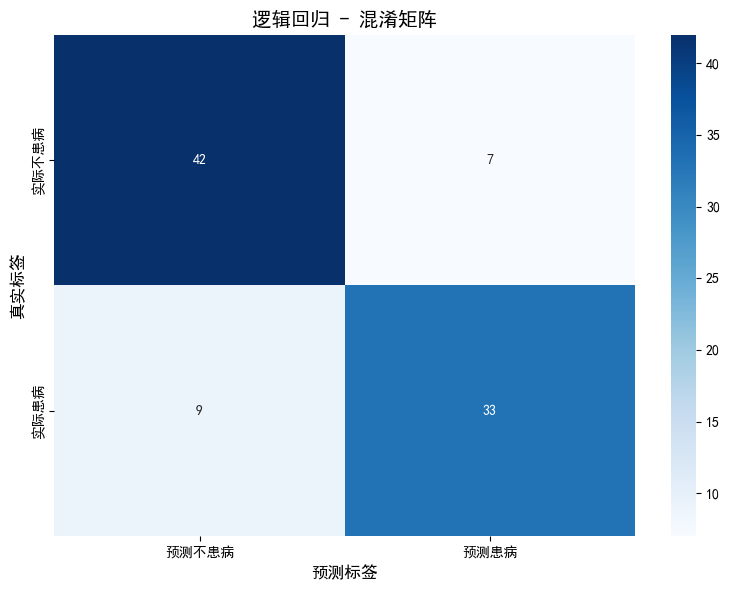

💡 混淆矩阵解读：
- 左上角(TN)：正确识别为不患病的人数
- 右上角(FP)：误诊（误判为患病）的人数
- 左下角(FN)：漏诊（误判为不患病）的人数
- 右下角(TP)：正确识别为患病的人数


In [11]:
# 可视化逻辑回归的混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['预测不患病', '预测患病'],
            yticklabels=['实际不患病', '实际患病'])
plt.title('逻辑回归 - 混淆矩阵', fontsize=14, fontweight='bold')
plt.ylabel('真实标签', fontsize=12)
plt.xlabel('预测标签', fontsize=12)
plt.tight_layout()
plt.show()

print("💡 混淆矩阵解读：")
print("- 左上角(TN)：正确识别为不患病的人数")
print("- 右上角(FP)：误诊（误判为患病）的人数")
print("- 左下角(FN)：漏诊（误判为不患病）的人数")
print("- 右下角(TP)：正确识别为患病的人数")

## **5.4 ROC曲线和AUC值**

**ROC曲线（Receiver Operating Characteristic）**：
- 横轴：假阳性率（FPR）= FP / (FP + TN)
- 纵轴：真阳性率（TPR）= TP / (TP + FN) = 召回率

**AUC值（Area Under Curve）**：
- ROC曲线下的面积
- 取值范围：[0, 1]
- AUC = 0.5：随机猜测
- AUC = 1.0：完美分类器
- 通常AUC > 0.8认为是较好的模型

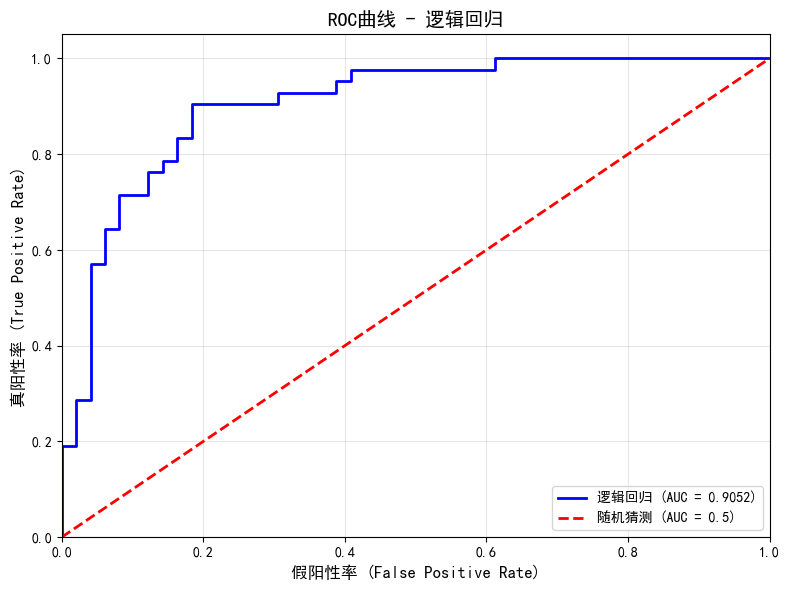


📊 AUC值：0.9052

💡 AUC值解读：
- AUC = 0.5：模型没有预测能力（等同于随机猜测）
- AUC = 0.7-0.8：模型有一定预测能力
- AUC = 0.8-0.9：模型预测能力较好
- AUC = 0.9-1.0：模型预测能力很好


In [12]:
# TODO: 计算ROC曲线和AUC值
# 提示：
# 1. 使用roc_curve函数计算FPR和TPR
# 2. 使用auc函数计算AUC值
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# 绘制ROC曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, 
         label=f'逻辑回归 (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--',
         label='随机猜测 (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假阳性率 (False Positive Rate)', fontsize=12)
plt.ylabel('真阳性率 (True Positive Rate)', fontsize=12)
plt.title('ROC曲线 - 逻辑回归', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 AUC值：{auc_lr:.4f}")
print("\n💡 AUC值解读：")
print("- AUC = 0.5：模型没有预测能力（等同于随机猜测）")
print("- AUC = 0.7-0.8：模型有一定预测能力")
print("- AUC = 0.8-0.9：模型预测能力较好")
print("- AUC = 0.9-1.0：模型预测能力很好")

## **5.5 评估决策树模型**

In [13]:
# TODO: 计算决策树模型的各项评估指标
dt_accuracy = accuracy_score(y_test, y_test_pred_dt)
dt_precision = precision_score(y_test, y_test_pred_dt)
dt_recall = recall_score(y_test, y_test_pred_dt)
dt_f1 = f1_score(y_test, y_test_pred_dt)

# 计算ROC曲线和AUC值
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_test_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

print("📊 决策树模型评估结果：")
print("="*50)
print(f"准确率: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"精确率: {dt_precision:.4f} ({dt_precision*100:.2f}%)")
print(f"召回率: {dt_recall:.4f} ({dt_recall*100:.2f}%)")
print(f"F1分数: {dt_f1:.4f}")
print(f"AUC值: {auc_dt:.4f}")

📊 决策树模型评估结果：
准确率: 0.7253 (72.53%)
精确率: 0.7576 (75.76%)
召回率: 0.5952 (59.52%)
F1分数: 0.6667
AUC值: 0.7942


## **5.6 评估随机森林模型**

In [14]:
# TODO: 计算决策树模型的各项评估指标
rf_accuracy = accuracy_score(y_test, y_test_pred_rf)
rf_precision = precision_score(y_test, y_test_pred_rf)
rf_recall = recall_score(y_test, y_test_pred_rf)
rf_f1 = f1_score(y_test, y_test_pred_rf)

# 计算ROC曲线和AUC值
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

print("📊 随机森林模型评估结果：")
print("="*50)
print(f"准确率: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"精确率: {rf_precision:.4f} ({rf_precision*100:.2f}%)")
print(f"召回率: {rf_recall:.4f} ({rf_recall*100:.2f}%)")
print(f"F1分数: {rf_f1:.4f}")
print(f"AUC值: {auc_rf:.4f}")

📊 随机森林模型评估结果：
准确率: 0.7692 (76.92%)
精确率: 0.7692 (76.92%)
召回率: 0.7143 (71.43%)
F1分数: 0.7407
AUC值: 0.8875


## **5.7 评估SVM模型**

In [15]:
# TODO: 计算SVM模型的各项评估指标
svm_accuracy = accuracy_score(y_test, y_test_pred_svm)
svm_precision = precision_score(y_test, y_test_pred_svm)
svm_recall = recall_score(y_test, y_test_pred_svm)
svm_f1 = f1_score(y_test, y_test_pred_svm)

# 计算ROC曲线和AUC值
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_test_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

print("📊 SVM模型评估结果：")
print("="*50)
print(f"准确率: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print(f"精确率: {svm_precision:.4f} ({svm_precision*100:.2f}%)")
print(f"召回率: {svm_recall:.4f} ({svm_recall*100:.2f}%)")
print(f"F1分数: {svm_f1:.4f}")
print(f"AUC值: {auc_svm:.4f}")

📊 SVM模型评估结果：
准确率: 0.8462 (84.62%)
精确率: 0.8684 (86.84%)
召回率: 0.7857 (78.57%)
F1分数: 0.8250
AUC值: 0.8805


## **5.8 四种模型对比**

📊 四种模型性能对比：
  模型    准确率    精确率    召回率     F1分数     AUC值
逻辑回归 0.8242 0.8250 0.7857 0.804878 0.905248
 决策树 0.7253 0.7576 0.5952 0.666667 0.794218
随机森林 0.7692 0.7692 0.7143 0.740741 0.887512
 SVM 0.8462 0.8684 0.7857 0.825000 0.880466


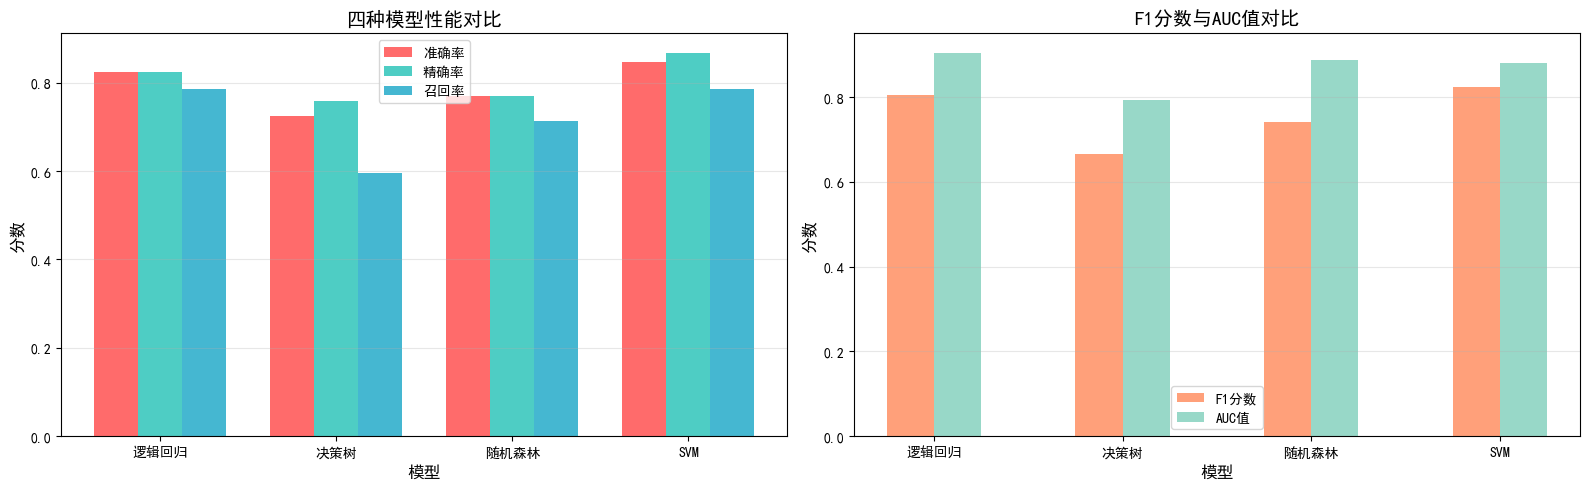


💡 结果分析：
- 观察哪种模型在各项指标上表现最好
- 在医疗场景中，召回率（漏诊率）往往更重要
- 综合考虑所有指标选择最适合的模型


In [16]:
# 对比四种模型的性能
comparison = pd.DataFrame({
    '模型': ['逻辑回归', '决策树', '随机森林', 'SVM'],
    '准确率': [lr_accuracy, dt_accuracy, rf_accuracy, svm_accuracy],
    '精确率': [lr_precision, dt_precision, rf_precision, svm_precision],
    '召回率': [lr_recall, dt_recall, rf_recall, svm_recall],
    'F1分数': [lr_f1, dt_f1, rf_f1, svm_f1],
    'AUC值': [auc_lr, auc_dt, auc_rf, auc_svm]
})

# 格式化输出
for col in ['准确率', '精确率', '召回率']:
    comparison[col] = comparison[col].apply(lambda x: f'{x:.4f}')

print("📊 四种模型性能对比：")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 柱状图1：准确率、精确率、召回率
x = np.arange(4)
width = 0.25

axes[0].bar(x - width, [lr_accuracy, dt_accuracy, rf_accuracy, accuracy_score(y_test, y_test_pred_svm)], 
           width, label='准确率', color='#FF6B6B')
axes[0].bar(x, [lr_precision, dt_precision, rf_precision, precision_score(y_test, y_test_pred_svm)], 
           width, label='精确率', color='#4ECDC4')
axes[0].bar(x + width, [lr_recall, dt_recall, rf_recall, recall_score(y_test, y_test_pred_svm)], 
           width, label='召回率', color='#45B7D1')

axes[0].set_xlabel('模型', fontsize=12)
axes[0].set_ylabel('分数', fontsize=12)
axes[0].set_title('四种模型性能对比', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['逻辑回归', '决策树', '随机森林', 'SVM'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# 柱状图2：F1分数和AUC值
axes[1].bar(x - width/2, [lr_f1, dt_f1, rf_f1, f1_score(y_test, y_test_pred_svm)], 
           width, label='F1分数', color='#FFA07A')
axes[1].bar(x + width/2, [auc_lr, auc_dt, auc_rf, auc(fpr_svm, tpr_svm)], 
           width, label='AUC值', color='#98D8C8')

axes[1].set_xlabel('模型', fontsize=12)
axes[1].set_ylabel('分数', fontsize=12)
axes[1].set_title('F1分数与AUC值对比', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['逻辑回归', '决策树', '随机森林', 'SVM'])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n💡 结果分析：")
print("- 观察哪种模型在各项指标上表现最好")
print("- 在医疗场景中，召回率（漏诊率）往往更重要")
print("- 综合考虑所有指标选择最适合的模型")

---
# **第六部分：特征重要性分析**

## **6.1 哪些特征对预测最重要？**

在医学应用中，理解哪些特征对预测结果最重要非常重要，这可以帮助我们：
- 了解哪些医学指标对心脏病预测最关键
- 在临床实践中优先关注重要指标
- 为医生提供诊断依据

In [17]:
# 逻辑回归的特征重要性（系数的绝对值）
feature_importance_lr = pd.DataFrame({
    '特征': numeric_columns,
    '重要性': np.abs(lr_model.coef_[0])
}).sort_values('重要性', ascending=False)

# 随机森林的特征重要性
feature_importance_rf = pd.DataFrame({
    '特征': numeric_columns,
    '重要性': rf_model.feature_importances_
}).sort_values('重要性', ascending=False)

print("📊 逻辑回归 - 特征重要性：")
print("="*40)
print(feature_importance_lr.to_string(index=False))

print("\n📊 随机森林 - 特征重要性：")
print("="*40)
print(feature_importance_rf.to_string(index=False))

📊 逻辑回归 - 特征重要性：
      特征      重要性
      ca 1.021030
     sex 0.827305
      cp 0.763772
    thal 0.563103
   exang 0.534602
   slope 0.412220
 oldpeak 0.376572
 thalach 0.345501
trestbps 0.222166
    chol 0.209459
 restecg 0.125576
     age 0.045463
     fbs 0.033383

📊 随机森林 - 特征重要性：
      特征      重要性
      cp 0.145374
 thalach 0.124281
    thal 0.116710
 oldpeak 0.104817
      ca 0.100733
   exang 0.078397
     age 0.078077
trestbps 0.076175
    chol 0.073362
   slope 0.043074
     sex 0.033493
 restecg 0.017976
     fbs 0.007532


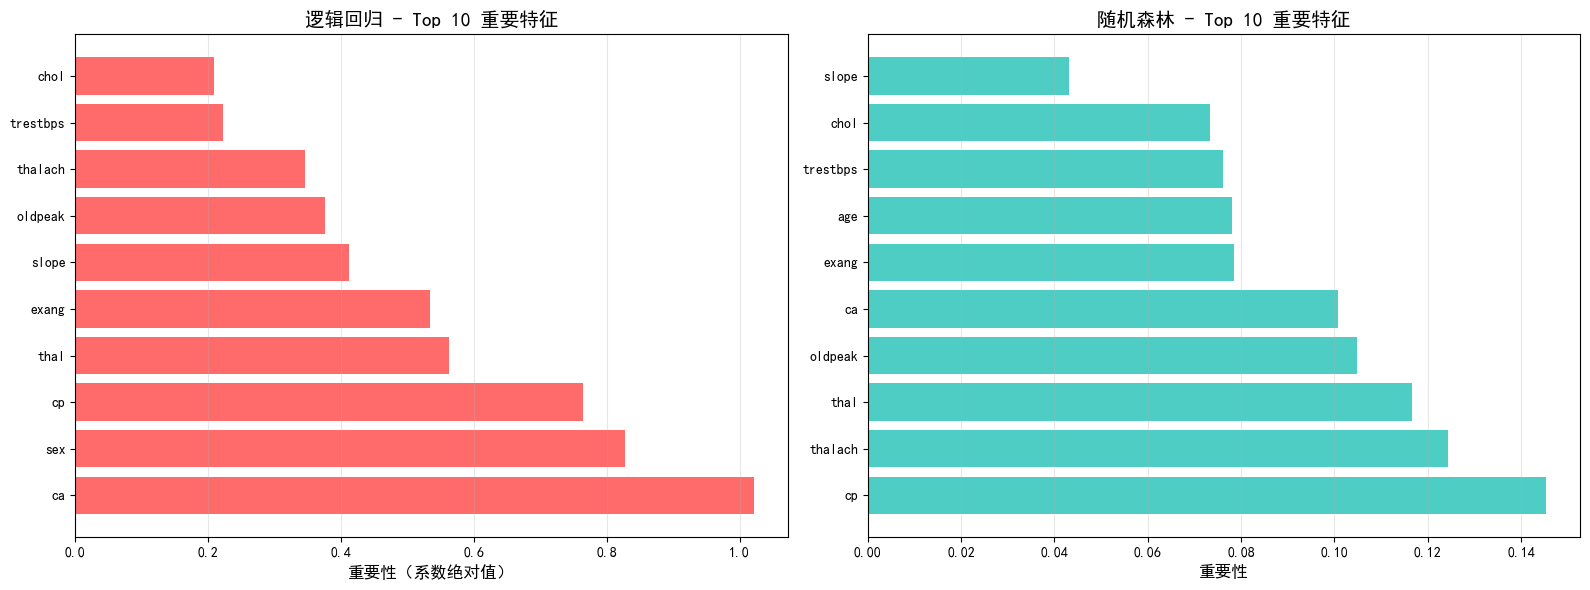

💡 特征重要性解读：
- 条形越长，表示该特征对预测结果影响越大
- 在临床实践中，可以重点关注这些重要指标
- 不同模型可能给出不同的重要性排序，这是正常的


In [18]:
# 可视化特征重要性
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 逻辑回归
axes[0].barh(feature_importance_lr['特征'][:10], 
            feature_importance_lr['重要性'][:10], 
            color='#FF6B6B')
axes[0].set_xlabel('重要性（系数绝对值）', fontsize=12)
axes[0].set_title('逻辑回归 - Top 10 重要特征', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# 随机森林
axes[1].barh(feature_importance_rf['特征'][:10], 
            feature_importance_rf['重要性'][:10], 
            color='#4ECDC4')
axes[1].set_xlabel('重要性', fontsize=12)
axes[1].set_title('随机森林 - Top 10 重要特征', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("💡 特征重要性解读：")
print("- 条形越长，表示该特征对预测结果影响越大")
print("- 在临床实践中，可以重点关注这些重要指标")
print("- 不同模型可能给出不同的重要性排序，这是正常的")

## **关键知识点回顾**

### **📚 分类的基本概念**
- **分类**：监督学习，预测离散类别
- **聚类**：无监督学习，发现数据结构
- **回归**：监督学习，预测连续数值

### **🤖 分类算法**
- **逻辑回归**：简单高效，可解释性强
- **决策树**：易于理解，可视化强
- **随机森林**：准确性高，不易过拟合

### **📊 评估指标**
- **准确率**：预测正确的比例
- **精确率**：预测为正的样本中真正为正的比例
- **召回率**：真正为正的样本中被正确预测的比例
- **F1分数**：精确率和召回率的调和平均
- **AUC值**：ROC曲线下的面积

## **扩展练习（可选）**

**挑战1**：尝试调整模型的超参数（如决策树的max_depth，随机森林的n_estimators），观察对性能的影响

**挑战2**：尝试其他分类算法（如KNN、神经网络），对比性能

**挑战3**：分析漏诊和误诊的具体案例，思考如何改进模型

**挑战4**：使用特征选择方法（如选择Top 5重要特征），对比只用重要特征训练模型的性能

**挑战5**：对比这周分类的结果和第三周聚类的结果，哪个结果更好，为什么？



---
## **🎓 课程结束**

**恭喜！** 你已经完成了从数据处理到分类模型构建的完整医学AI实践流程。

**今天你学会了**：
- ✅ 理解分类的基本原理
- ✅ 掌握分类、聚类、回归的区别
- ✅ 数据划分（训练集/测试集）
- ✅ 逻辑回归、决策树、随机森林三种分类算法
- ✅ 模型评估指标（准确率、精确率、召回率、F1、AUC）
- ✅ 特征重要性分析

**下一步建议**：
- 尝试不同的特征组合
- 调整模型超参数
- 学习更多分类算法
- 了解模型的可解释性